         Date     Close      High       Low      Open      Volume
0  2002-05-23  0.119643  0.124286  0.114571  0.115643  1047900000
1  2002-05-24  0.121000  0.122500  0.119714  0.121429   111048000
2  2002-05-28  0.115714  0.123214  0.115714  0.121357    66094000
3  2002-05-29  0.110357  0.116429  0.108571  0.116429    67578000
4  2002-05-30  0.107143  0.110786  0.107143  0.110786   101542000


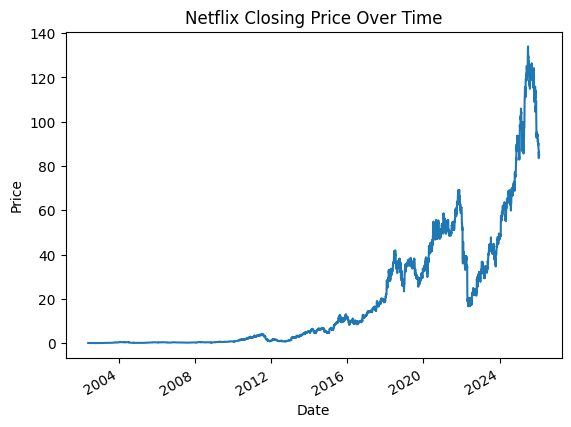

<Figure size 640x480 with 0 Axes>

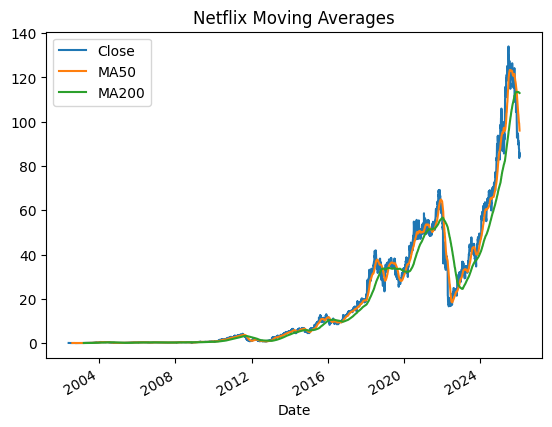

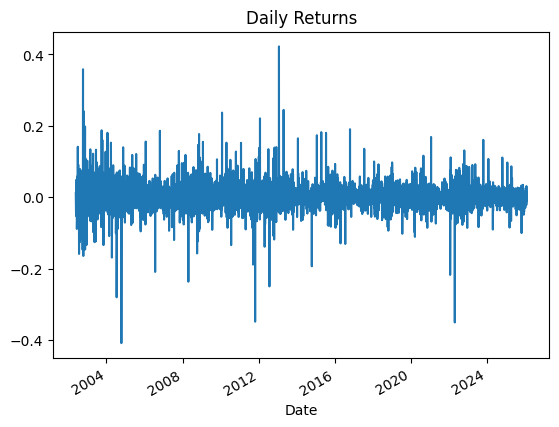

Volatility: 0.03442779987809269


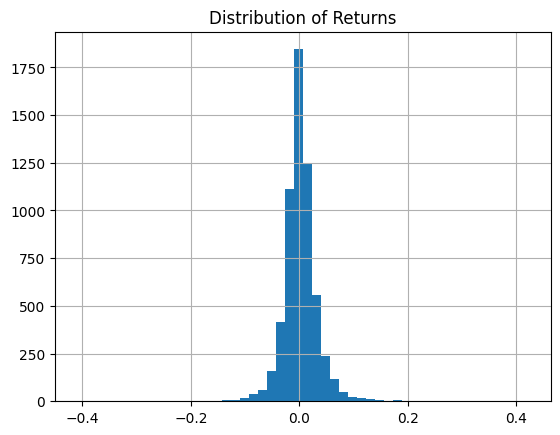

Max Price: 133.91299438476562
Min Price: 0.0372859984636306


/tmp/ipykernel_7166/4210713563.py:72: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Signal'][50:] = (df['MA50'][50:] > df['MA200'][50:]).astype(int)
/tmp/ipykernel_7166/4210713563.py:72: SettingWithCopyWarning: 
A value is trying to be s

<Figure size 640x480 with 0 Axes>

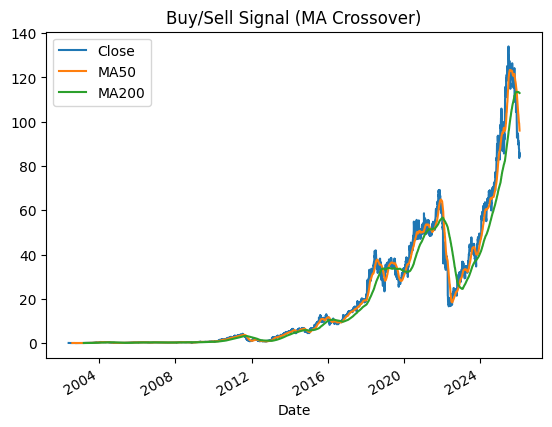

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("NFLX.csv")  # change name if needed

# Preview data
print(df.head())

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Sort (important)
df = df.sort_index()

# -----------------------------
# 📈 1. Closing Price Plot
# -----------------------------
plt.figure()
df['Close'].plot()
plt.title("Netflix Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

# -----------------------------
# 📊 2. Moving Averages
# -----------------------------
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()

plt.figure()
df[['Close', 'MA50', 'MA200']].plot()
plt.title("Netflix Moving Averages")
plt.show()

# -----------------------------
# 📉 3. Daily Returns
# -----------------------------
df['Daily Return'] = df['Close'].pct_change()

plt.figure()
df['Daily Return'].plot()
plt.title("Daily Returns")
plt.show()

# -----------------------------
# 📦 4. Volatility (Risk)
# -----------------------------
volatility = df['Daily Return'].std()
print("Volatility:", volatility)

# -----------------------------
# 📊 5. Histogram of Returns
# -----------------------------
plt.figure()
df['Daily Return'].hist(bins=50)
plt.title("Distribution of Returns")
plt.show()

# -----------------------------
# 🔥 6. Highest & Lowest Price
# -----------------------------
print("Max Price:", df['Close'].max())
print("Min Price:", df['Close'].min())

# -----------------------------
# 🚀 7. Simple Buy/Sell Signal
# -----------------------------
df['Signal'] = 0
df['Signal'][50:] = (df['MA50'][50:] > df['MA200'][50:]).astype(int)

plt.figure()
df[['Close', 'MA50', 'MA200']].plot()
plt.title("Buy/Sell Signal (MA Crossover)")
plt.show()

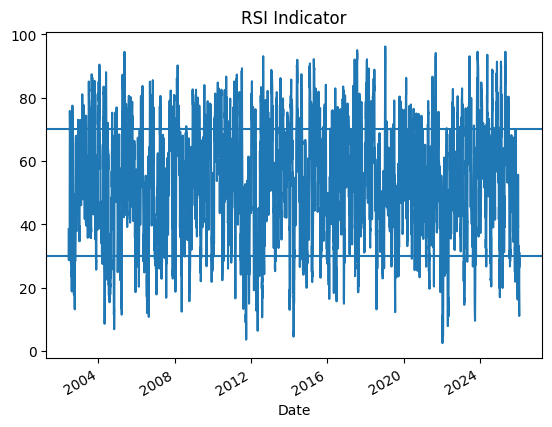

In [ ]:
# RSI Calculation
delta = df['Close'].diff()

gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()

rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# Plot RSI
import matplotlib.pyplot as plt
plt.figure()
df['RSI'].plot()
plt.axhline(70)
plt.axhline(30)
plt.title("RSI Indicator")
plt.show()

<Figure size 640x480 with 0 Axes>

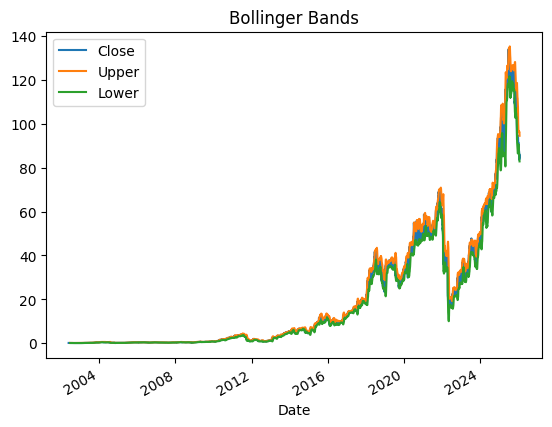

In [ ]:
df['MA20'] = df['Close'].rolling(window=20).mean()
df['STD'] = df['Close'].rolling(window=20).std()

df['Upper'] = df['MA20'] + (2 * df['STD'])
df['Lower'] = df['MA20'] - (2 * df['STD'])

plt.figure()
df[['Close', 'Upper', 'Lower']].plot()
plt.title("Bollinger Bands")
plt.show()

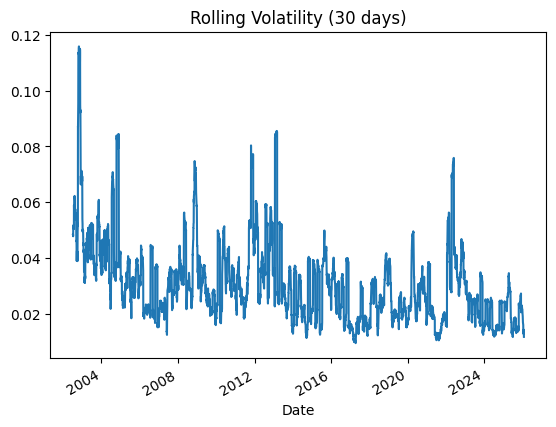

In [ ]:
df['Rolling Volatility'] = df['Daily Return'].rolling(window=30).std()

plt.figure()
df['Rolling Volatility'].plot()
plt.title("Rolling Volatility (30 days)")
plt.show()

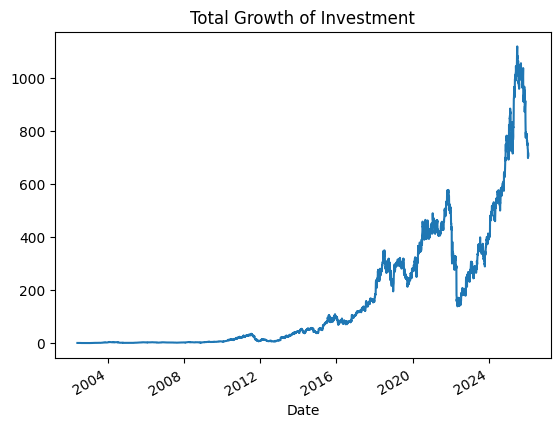

In [ ]:
df['Cumulative Return'] = (1 + df['Daily Return']).cumprod()

plt.figure()
df['Cumulative Return'].plot()
plt.title("Total Growth of Investment")
plt.show()

<Figure size 640x480 with 0 Axes>

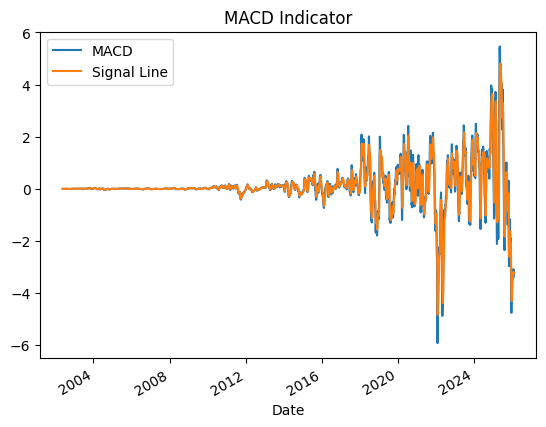

In [ ]:
exp1 = df['Close'].ewm(span=12, adjust=False).mean()
exp2 = df['Close'].ewm(span=26, adjust=False).mean()

df['MACD'] = exp1 - exp2
df['Signal Line'] = df['MACD'].ewm(span=9, adjust=False).mean()

plt.figure()
df[['MACD', 'Signal Line']].plot()
plt.title("MACD Indicator")
plt.show()

In [16]:
df2 = pd.read_csv("AAPL.csv")
df2['Date'] = pd.to_datetime(df2['Date'], dayfirst=True)
df2.set_index('Date', inplace=True)

combined = pd.concat([df['Close'], df2['Close']], axis=1)
combined.columns = ['Netflix', 'Apple']

print(combined.corr())

         Netflix   Apple
Netflix   1.0000  0.8561
Apple     0.8561  1.0000


         Date      Open      High       Low     Close  Day Difference  \
0  12-12-1980  0.128348  0.128906  0.128348  0.128348         0.00000   
1  15-12-1980  0.122210  0.122210  0.121652  0.121652        -0.00056   
2  16-12-1980  0.113281  0.113281  0.112723  0.112723        -0.00056   
3  17-12-1980  0.115513  0.116071  0.115513  0.115513         0.00000   
4  18-12-1980  0.118862  0.119420  0.118862  0.118862         0.00000   

   Adj Close       Volume  
0   0.099450  469033600.0  
1   0.094261  175884800.0  
2   0.087343  105728000.0  
3   0.089504   86441600.0  
4   0.092099   73449600.0  


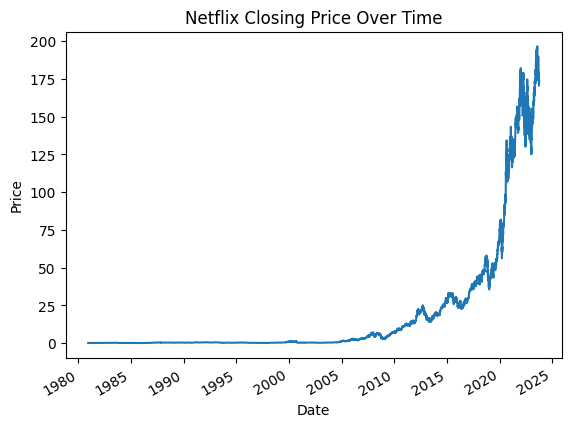

<Figure size 640x480 with 0 Axes>

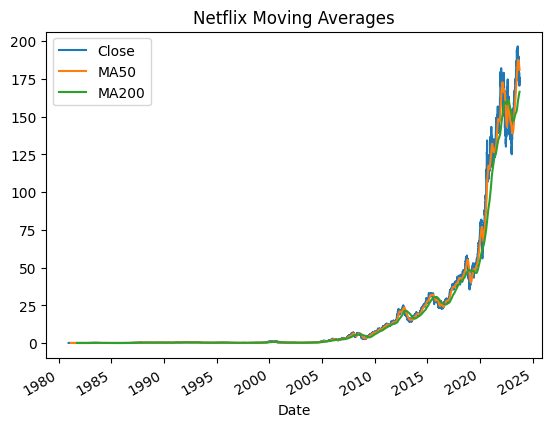

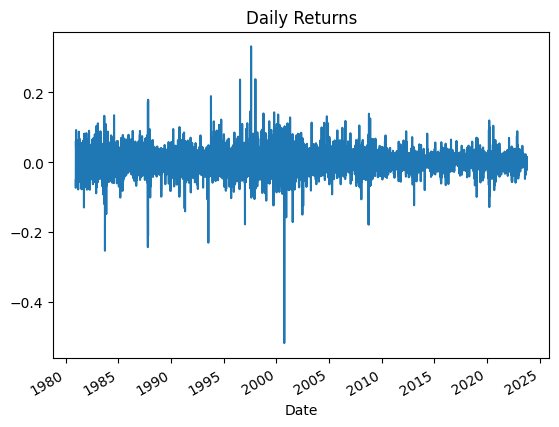

Volatility: 0.02809432114063713


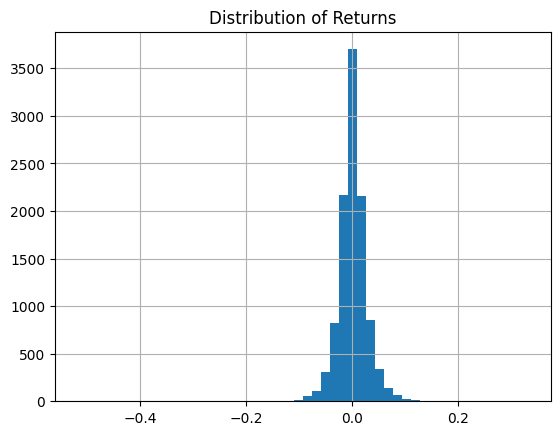

Max Price: 196.449997
Min Price: 0.049107


/tmp/ipykernel_7166/3900563879.py:72: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Signal'][50:] = (df['MA50'][50:] > df['MA200'][50:]).astype(int)
/tmp/ipykernel_7166/3900563879.py:72: SettingWithCopyWarning: 
A value is trying to be s

<Figure size 640x480 with 0 Axes>

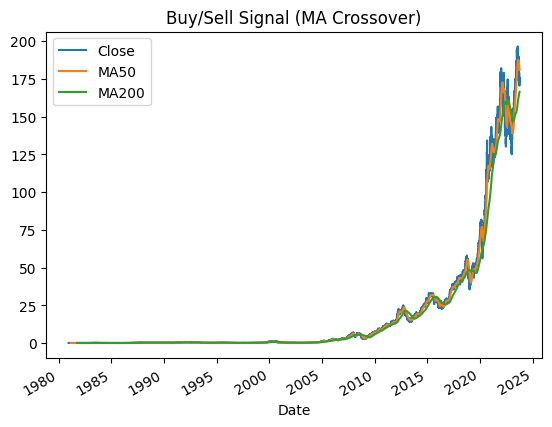

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("AAPL.csv")  # change name if needed

# Preview data
print(df.head())

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.set_index('Date', inplace=True)

# Sort (important)
df = df.sort_index()

# -----------------------------
# 📈 1. Closing Price Plot
# -----------------------------
plt.figure()
df['Close'].plot()
plt.title("Netflix Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

# -----------------------------
# 📊 2. Moving Averages
# -----------------------------
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()

plt.figure()
df[['Close', 'MA50', 'MA200']].plot()
plt.title("Netflix Moving Averages")
plt.show()

# -----------------------------
# 📉 3. Daily Returns
# -----------------------------
df['Daily Return'] = df['Close'].pct_change()

plt.figure()
df['Daily Return'].plot()
plt.title("Daily Returns")
plt.show()

# -----------------------------
# 📦 4. Volatility (Risk)
# -----------------------------
volatility = df['Daily Return'].std()
print("Volatility:", volatility)

# -----------------------------
# 📊 5. Histogram of Returns
# -----------------------------
plt.figure()
df['Daily Return'].hist(bins=50)
plt.title("Distribution of Returns")
plt.show()

# -----------------------------
# 🔥 6. Highest & Lowest Price
# -----------------------------
print("Max Price:", df['Close'].max())
print("Min Price:", df['Close'].min())

# -----------------------------
# 🚀 7. Simple Buy/Sell Signal
# -----------------------------
df['Signal'] = 0
df['Signal'][50:] = (df['MA50'][50:] > df['MA200'][50:]).astype(int)

plt.figure()
df[['Close', 'MA50', 'MA200']].plot()
plt.title("Buy/Sell Signal (MA Crossover)")
plt.show()